In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import(
    train_test_split,
    GridSearchCV)

from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import(
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier)
from sklearn import metrics
from sklearn.metrics import(
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score)

from xgboost import XGBClassifier


In [4]:
wine = pd.read_csv('winequality.csv', sep=';')
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
data = wine.copy()

In [6]:
data.shape, data.tail()

((1599, 12),
       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
 1594            6.2             0.600         0.08             2.0      0.090   
 1595            5.9             0.550         0.10             2.2      0.062   
 1596            6.3             0.510         0.13             2.3      0.076   
 1597            5.9             0.645         0.12             2.0      0.075   
 1598            6.0             0.310         0.47             3.6      0.067   
 
       free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
 1594                 32.0                  44.0  0.99490  3.45       0.58   
 1595                 39.0                  51.0  0.99512  3.52       0.76   
 1596                 29.0                  40.0  0.99574  3.42       0.75   
 1597                 32.0                  44.0  0.99547  3.57       0.71   
 1598                 18.0                  42.0  0.99549  3.39       0.66   
 
       alcohol  quality

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


## Exploratory Data Analysis

### Univariate analysis

In [11]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

#### Observations on fixed acidity

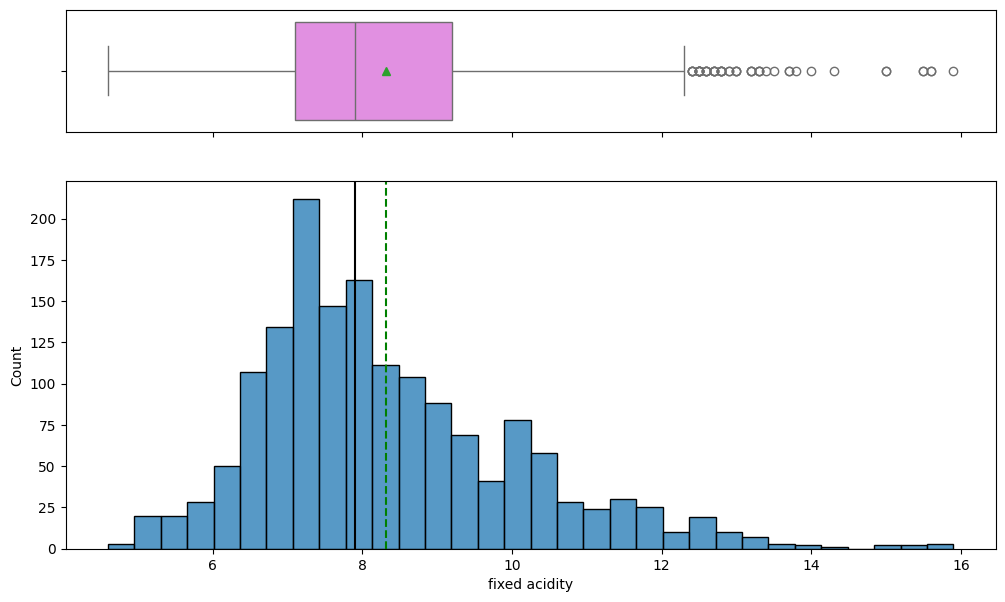

In [12]:
histogram_boxplot(data,'fixed acidity')

#### Observations on volatile acidity

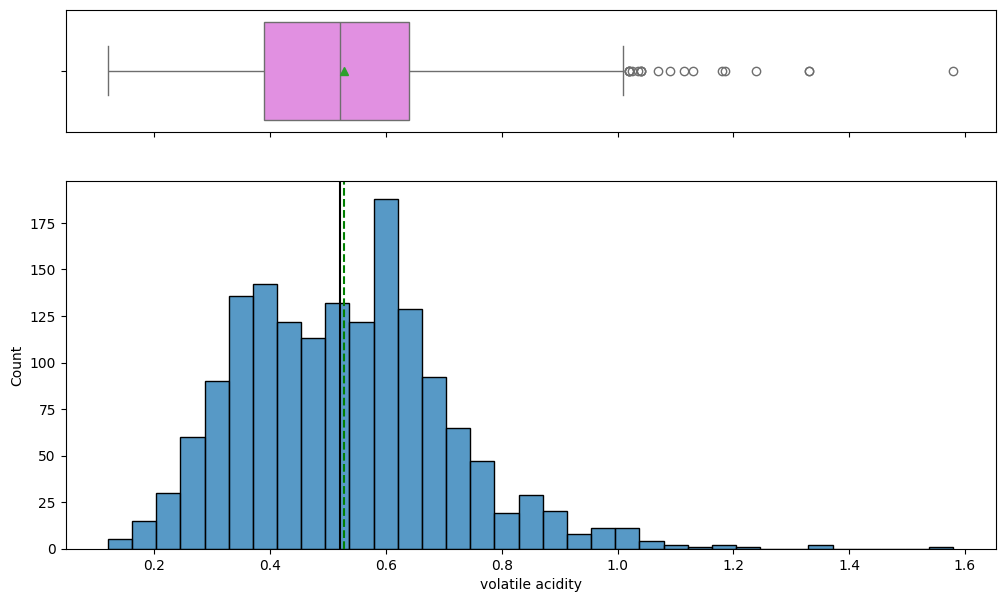

In [13]:
histogram_boxplot(data,'volatile acidity')

#### Observations on citric acid

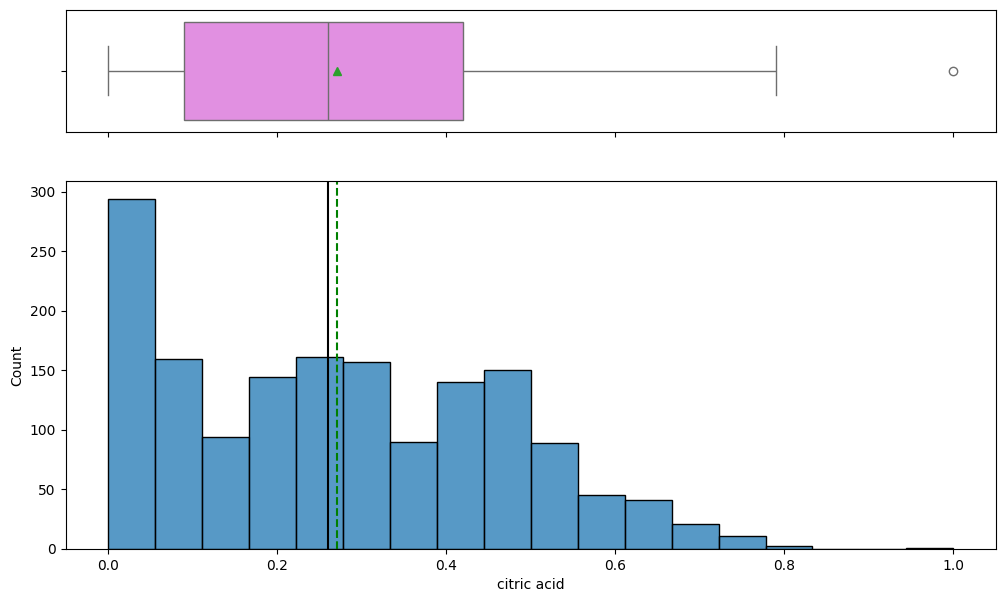

In [15]:
histogram_boxplot(data, 'citric acid')

#### Observations on residual sugar

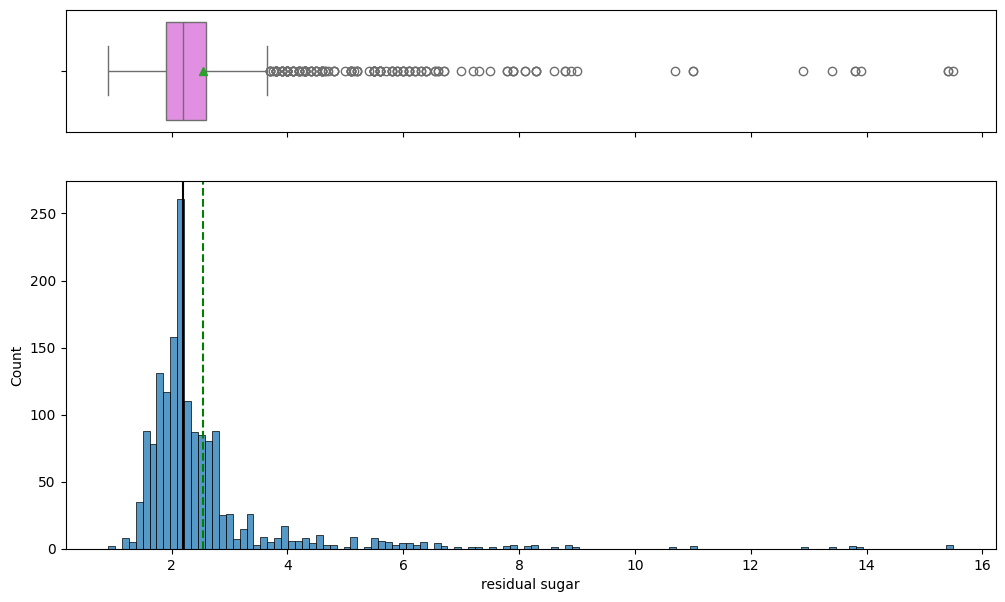

In [16]:
histogram_boxplot(data,'residual sugar')

#### Observations on chlorides

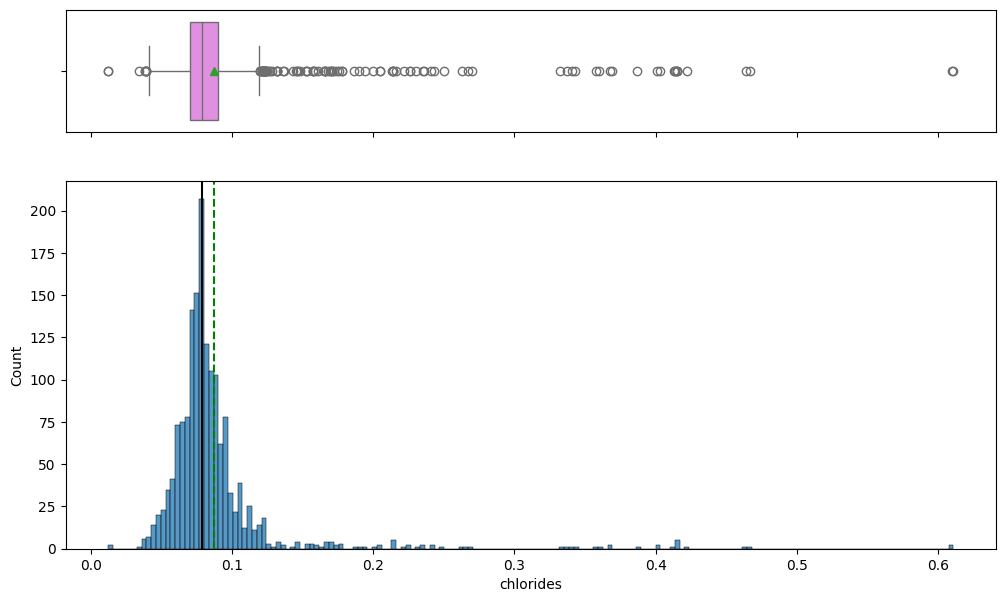

In [17]:
histogram_boxplot(data,'chlorides')

#### Observations on free sulfur dioxide

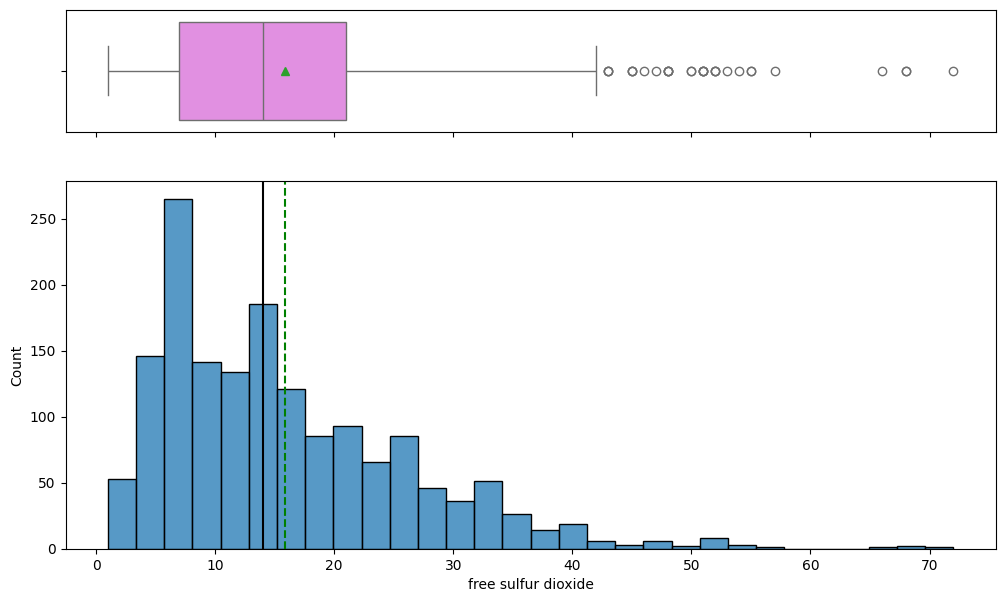

In [18]:
histogram_boxplot(data, 'free sulfur dioxide')

#### Observations on total sulfur dioxide

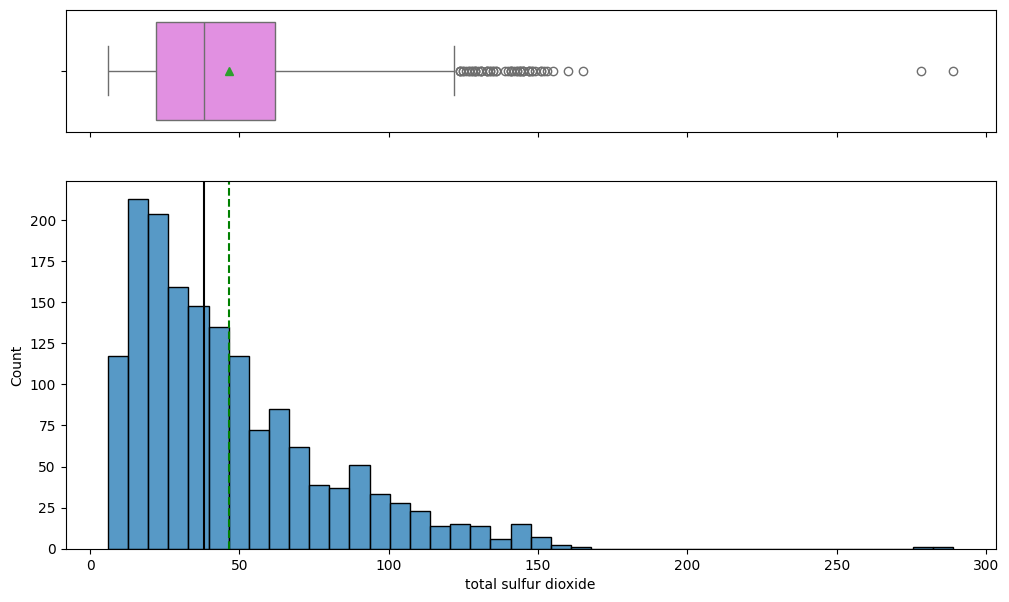

In [19]:
histogram_boxplot(data,'total sulfur dioxide')

In [20]:
data['total sulfur dioxide'].sort_values(ascending=False).head()

1081    289.0
1079    278.0
354     165.0
1244    160.0
651     155.0
Name: total sulfur dioxide, dtype: float64

In [21]:
# Cap the extreme value above to a specified number
data['total sulfur dioxide'] = data['total sulfur dioxide'].clip(upper=165)

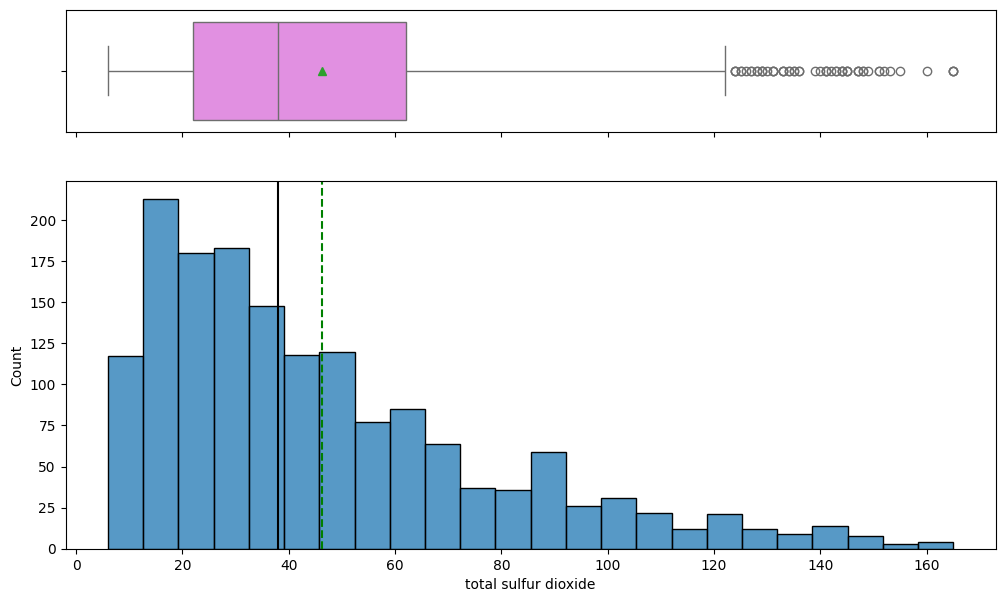

In [22]:
histogram_boxplot(data,'total sulfur dioxide')

#### Observations on density

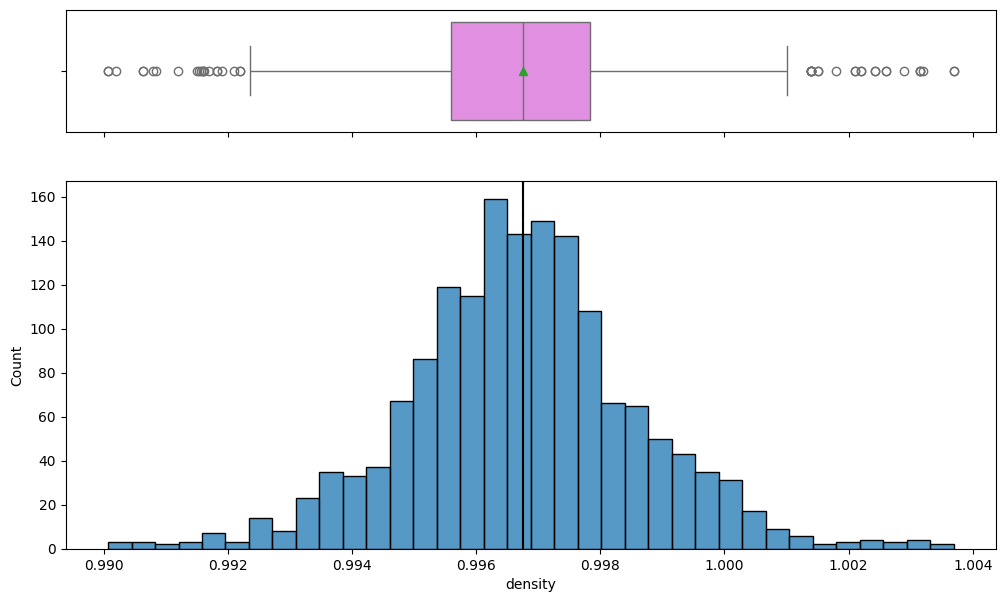

In [23]:
histogram_boxplot(data,'density')

#### Observations on pH

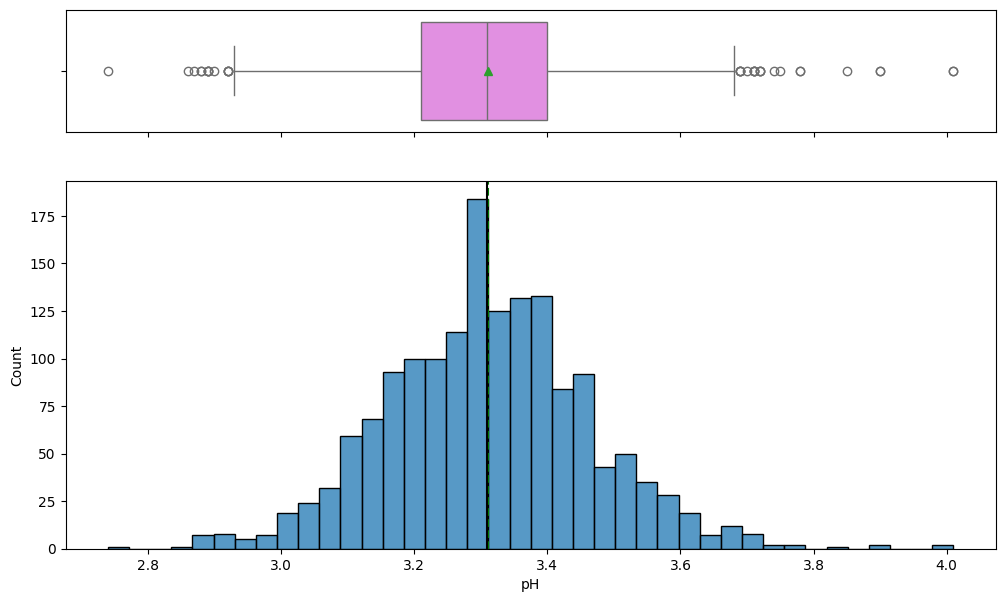

In [24]:
histogram_boxplot(data,'pH')

#### Observations on sulphates

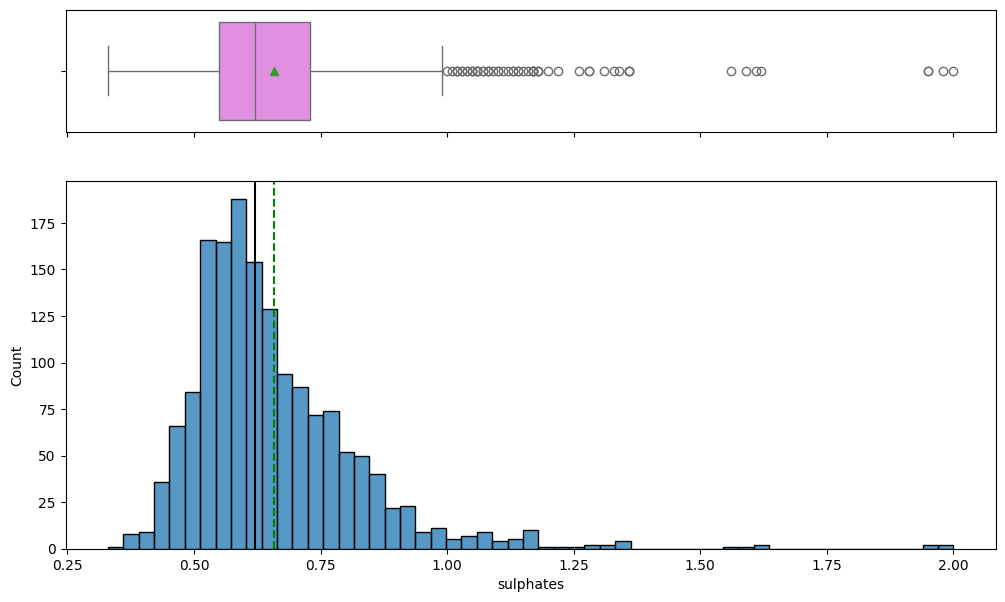

In [26]:
histogram_boxplot(data, 'sulphates')

#### Observations on alcohol

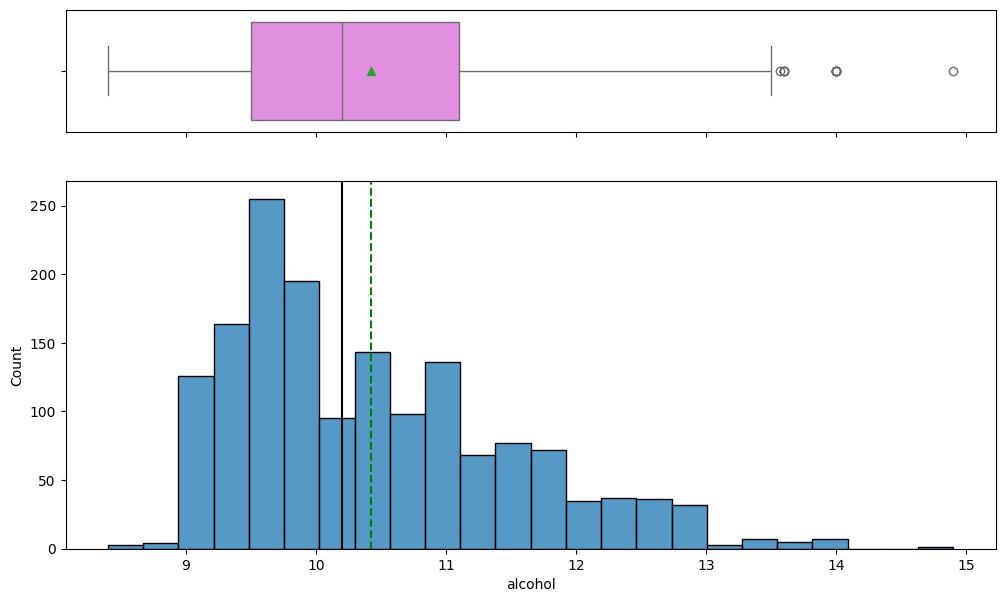

In [27]:
histogram_boxplot(data,'alcohol')

In [28]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

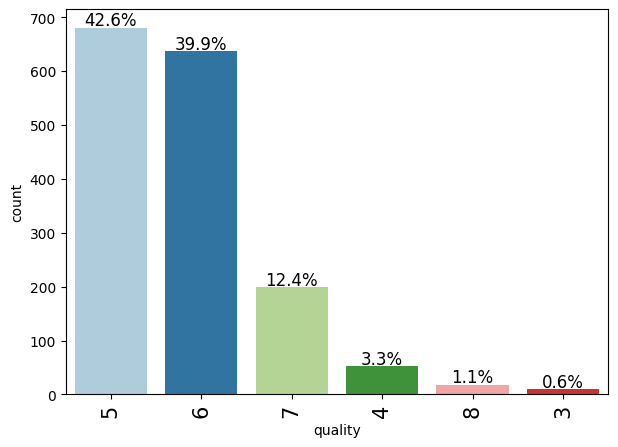

In [30]:
labeled_barplot(data, 'quality', perc=True)

In [31]:
# create 2 bins of wine quality to be used in prediction
bins = (2,6,8)
labels = ['non-premium','premium']
data['quality_class'] = pd.cut(x = data['quality'],
                               bins = bins,
                               labels = labels)

In [32]:
data['quality_class'].value_counts()

quality_class
non-premium    1382
premium         217
Name: count, dtype: int64

### Bivariate Analysis

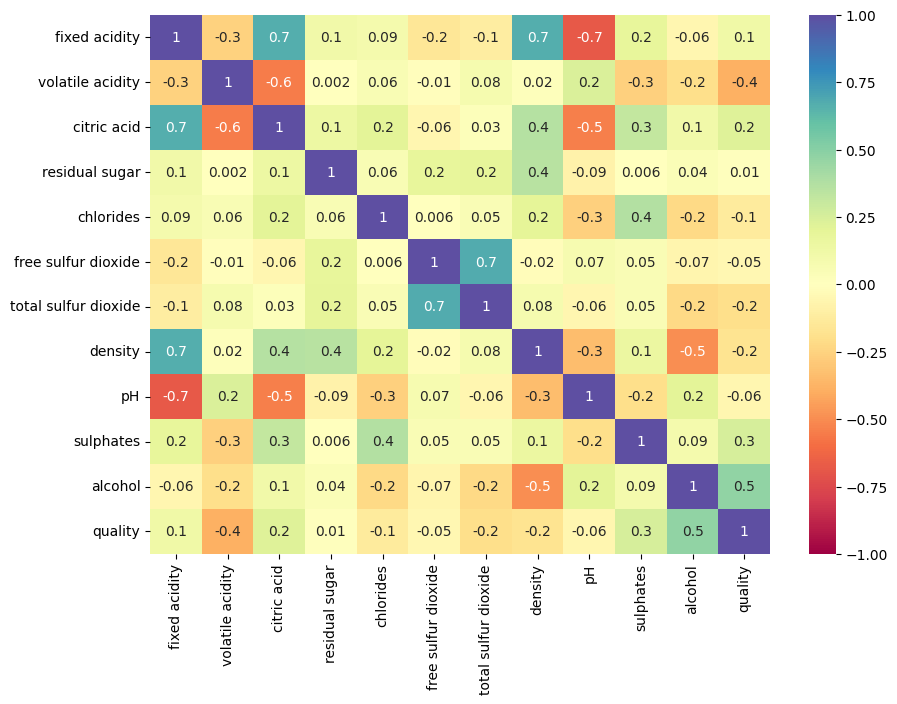

In [35]:
plt.figure(figsize=(10,7))
sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            vmin=-1,
            vmax=1,
            fmt='0.1g',
            cmap='Spectral')
plt.show()

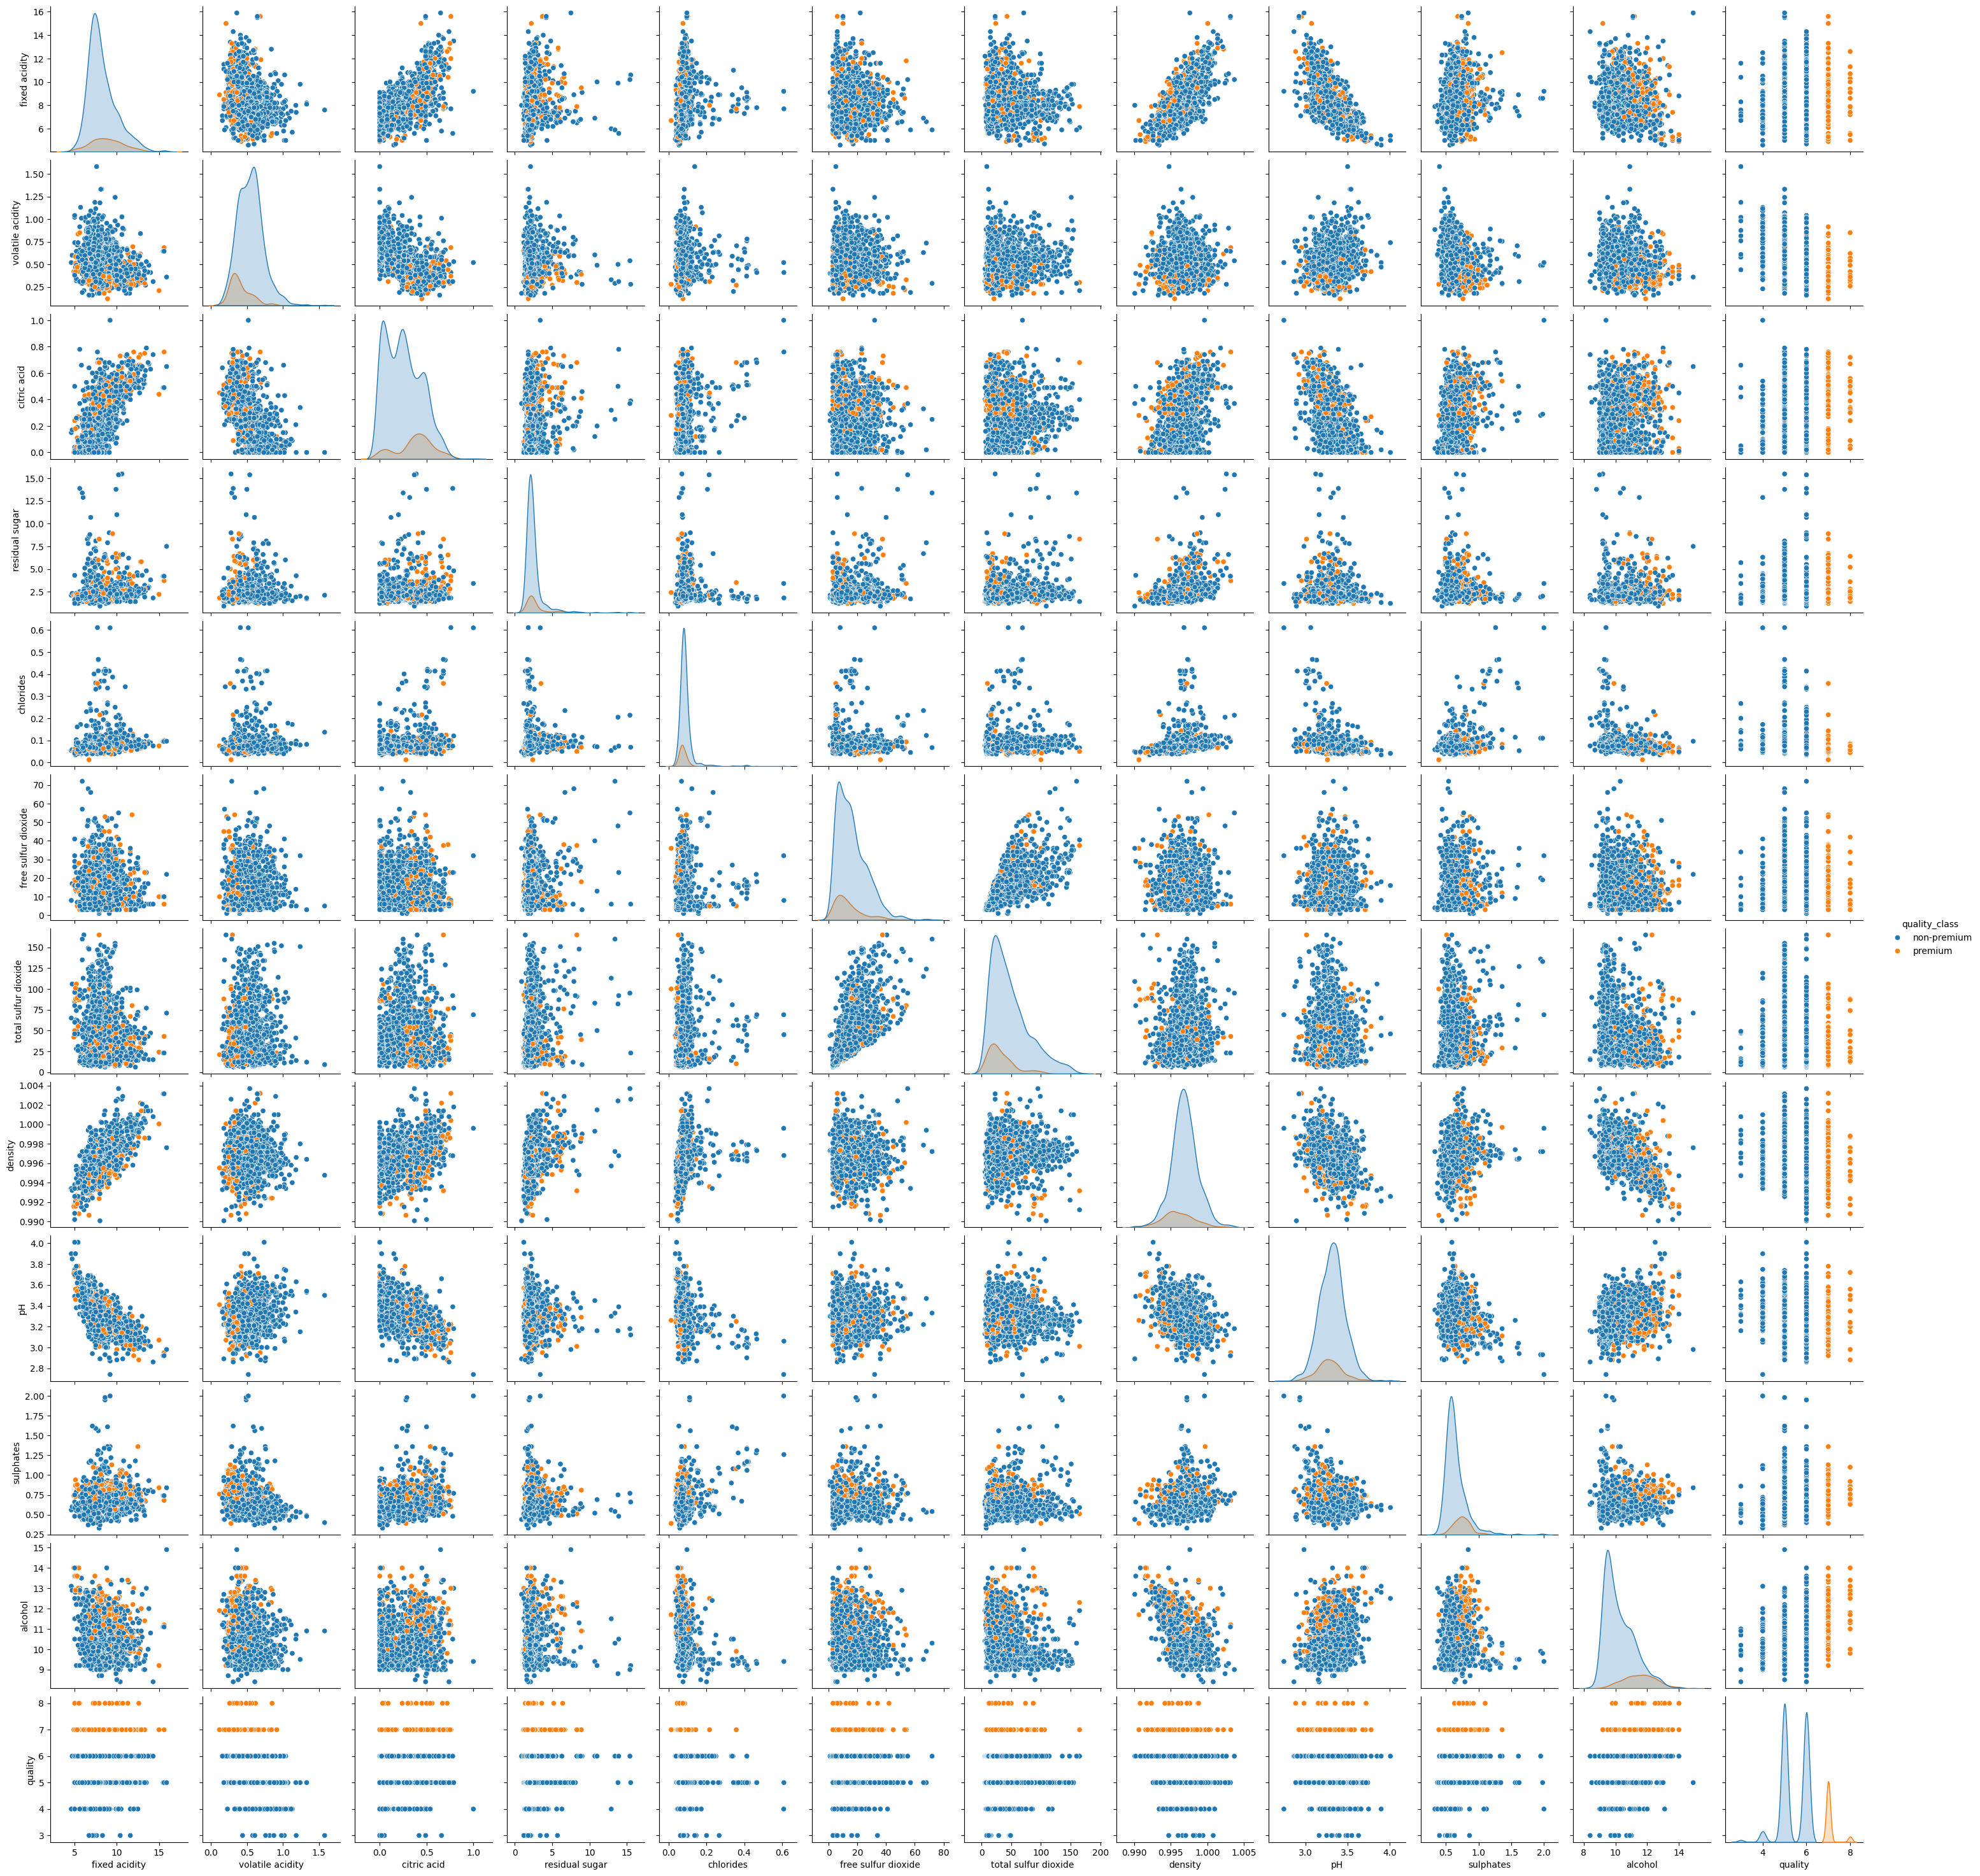

In [37]:
sns.pairplot(data, hue='quality_class')
plt.show()

#### Quality vs acidity

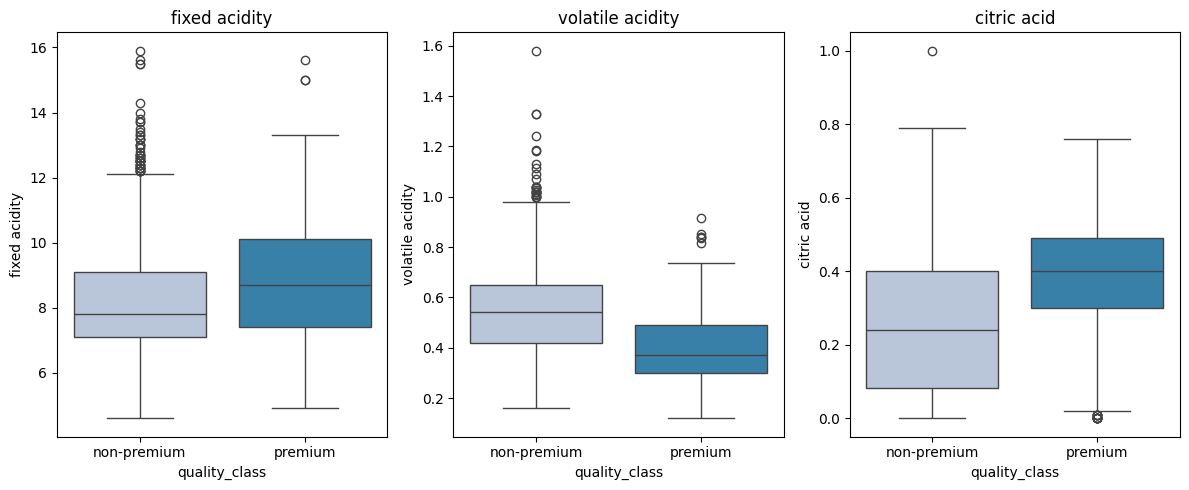

In [39]:
cols = data[['fixed acidity',
             'volatile acidity',
             'citric acid']].columns.tolist()
plt.figure(figsize=(12,5))
for i,variable in enumerate(cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(x=data['quality_class'],
                y=data[variable],
                palette='PuBu')
    plt.tight_layout()
    plt.title(variable)
plt.show()    

#### Quality vs sulfur

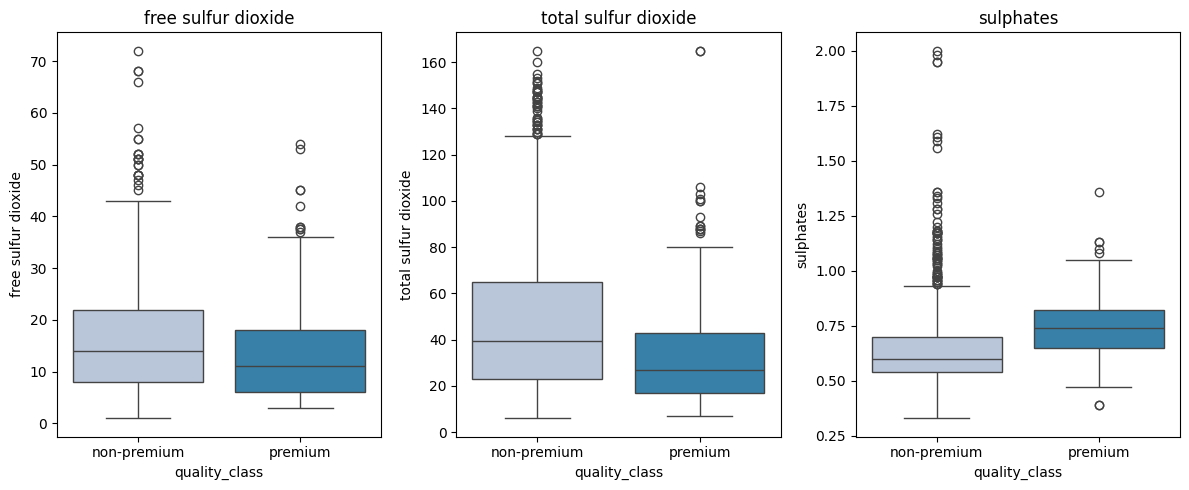

In [40]:
cols = data[['free sulfur dioxide',
             'total sulfur dioxide',
             'sulphates']].columns.tolist()
plt.figure(figsize=(12,5))

for i, variable in enumerate(cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(x=data['quality_class'],
                y=data[variable],
                palette='PuBu')
    plt.tight_layout()
    plt.title(variable)
plt.show()

#### Quality vs chlorides

In [41]:
def boxplot(y):
    plt.figure(figsize=(7,5))
    sns.boxplot(x=data['quality_class'],
                y=y,
                palette = 'PuBu')
    plt.show()

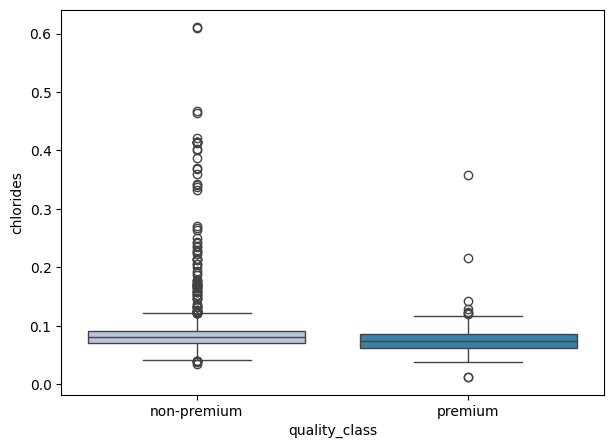

In [43]:
boxplot(data['chlorides'])

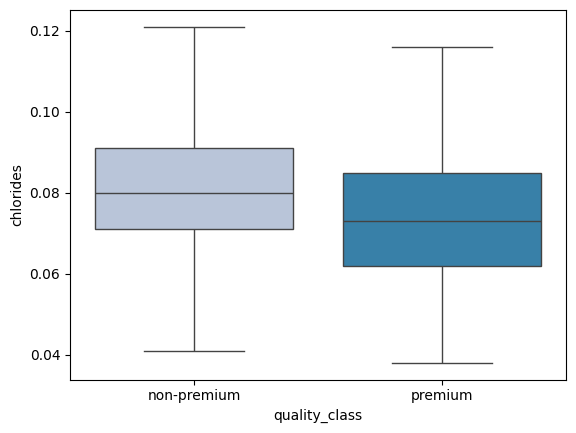

In [45]:
# create boxplot but hide the outliers (showfliers)
sns.boxplot(x = data['quality_class'], y = data['chlorides'],showfliers=False,palette='PuBu');

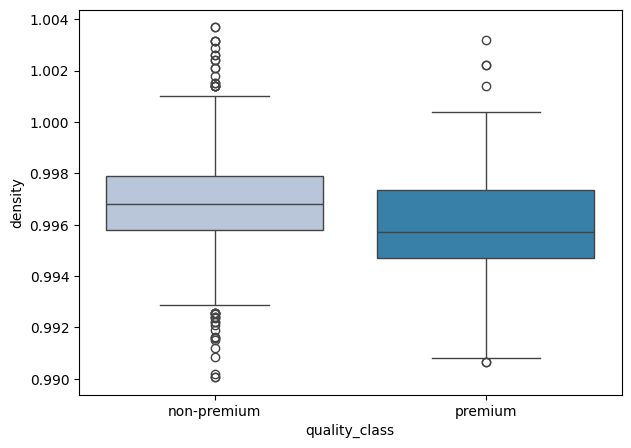

In [46]:
boxplot(data['density'])

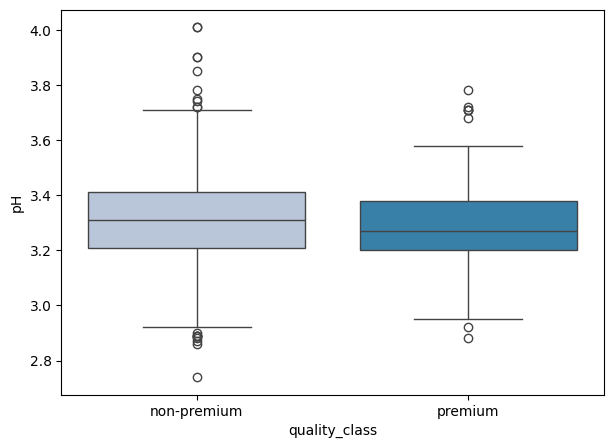

In [47]:
boxplot(data['pH'])

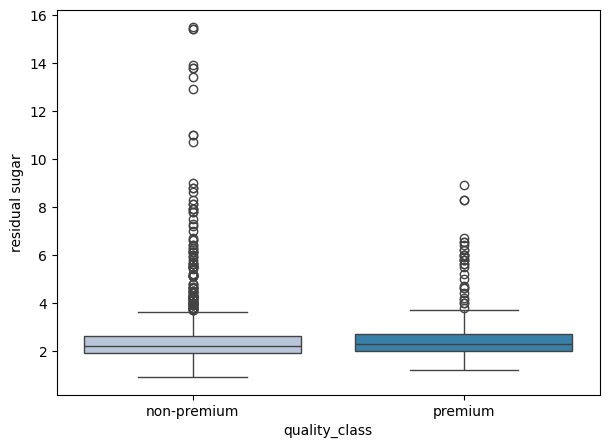

In [48]:
boxplot(data['residual sugar'])

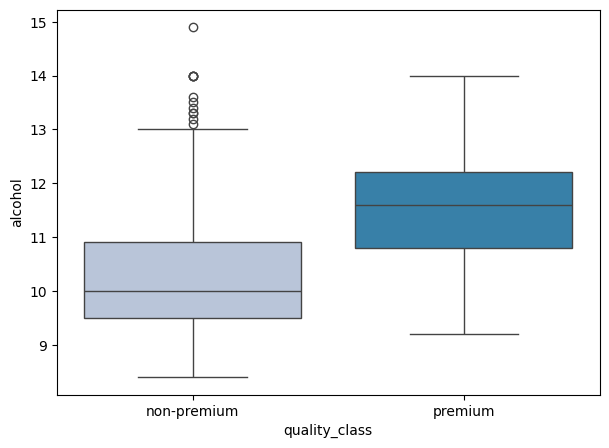

In [49]:
boxplot(data['alcohol'])

## Data Preprocessing

In [51]:
data.drop('quality', axis=1, inplace=True)
X = data.drop('quality_class', axis=1)
y = data['quality_class'].apply(lambda x: 0 if x=='non-premium' else 1)

In [53]:
(X_train, X_test,
 y_train, y_test) = train_test_split(X, 
                                     y, 
                                     test_size=0.3,
                                     random_state=1,
                                     stratify=y)
print(X_train.shape, X_test.shape)

(1119, 11) (480, 11)


In [57]:
# Show count breakdown and percentage breakdown for the y target
y.value_counts(), y.value_counts(1)

(quality_class
 0    1382
 1     217
 Name: count, dtype: int64,
 quality_class
 0    0.86429
 1    0.13571
 Name: proportion, dtype: float64)

## Model Evaluation Criteria

In [61]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

In [72]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Decision Tree Classifier

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Testing performance:
    Accuracy  Recall  Precision        F1
0    0.8875     0.6    0.58209  0.590909


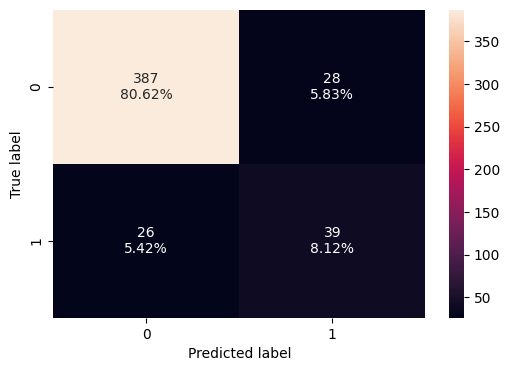

In [73]:
d_tree = DecisionTreeClassifier(random_state=1).fit(X_train,y_train)

d_tree_model_train_perf=model_performance(d_tree, X_train, y_train)
print("Training performance:\n",d_tree_model_train_perf)
d_tree_model_test_perf=model_performance(d_tree, X_test, y_test)
print("Testing performance:\n",d_tree_model_test_perf)

confusion_matrix_sklearn(d_tree, X_test, y_test)

### Decision Tree Classifier Hyperparameter Tuning Model

In [69]:
dtree_estimator = DecisionTreeClassifier(class_weight='balanced',
                                         random_state=1)

parameters = {
    'max_depth': np.arange(2,30),
    'min_samples_leaf': [1,2,5,7,10],
    'max_leaf_nodes': [2,3,5,10,15],
    'min_impurity_decrease': [0.0001,0.001,0.01,0.1]}

scorer = metrics.make_scorer(metrics.f1_score)
grid_obj = GridSearchCV(dtree_estimator,
                        parameters,
                        scoring=scorer,
                        n_jobs=-1).fit(X_train, y_train)
dtree_estimator = grid_obj.best_estimator_
dtree_estimator.fit(X_train, y_train)



DecisionTreeClassifier(class_weight='balanced', max_depth=7, max_leaf_nodes=15,
                       min_impurity_decrease=0.0001, min_samples_leaf=10,
                       random_state=1)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.812332  0.921053   0.414201  0.571429
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.760417  0.876923   0.347561  0.497817


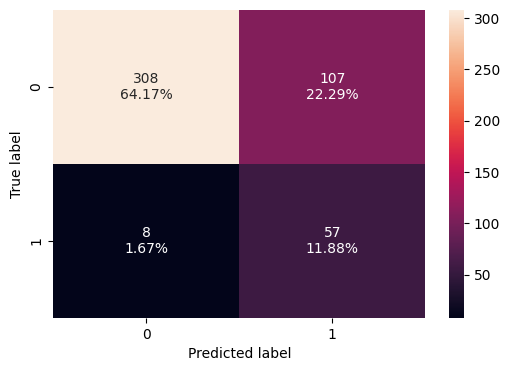

In [74]:
dtree_estimator_model_train_perf = model_performance(dtree_estimator,
                                                     X_train,
                                                     y_train)
print("Training performance:\n",dtree_estimator_model_train_perf)
dtree_estimator_model_test_perf = model_performance(dtree_estimator,
                                                    X_test,
                                                    y_test)
print("Testing performance:\n",dtree_estimator_model_test_perf)

confusion_matrix_sklearn(dtree_estimator, X_test, y_test)

## Bagging

### Random Forest Classifier

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Testing performance:
    Accuracy    Recall  Precision        F1
0   0.91875  0.492308   0.842105  0.621359


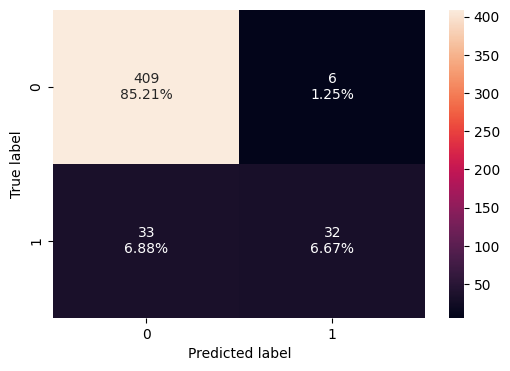

In [76]:
rf_estimator = RandomForestClassifier(random_state=1).fit(X_train, y_train)

rf_estimator_model_train_perf=model_performance(rf_estimator,
                                                X_train,
                                                y_train)
print("Training performance:\n",rf_estimator_model_train_perf)
rf_estimator_model_test_perf=model_performance(rf_estimator,
                                               X_test,
                                               y_test)
print("Testing performance:\n",rf_estimator_model_test_perf)

confusion_matrix_sklearn(rf_estimator,X_test, y_test)

### Hyperparameter Tuning

In [78]:
rf_tuned = RandomForestClassifier(class_weight='balanced',
                                  random_state=1,
                                  oob_score=True,
                                  bootstrap=True)

parameters = {
    'max_depth': list(np.arange(5,30,5)) + [None],
    'max_features': ['sqrt','log2',None],
    'min_samples_leaf': np.arange(1,15,5),
    'min_samples_split': np.arange(2,20,5),
    'n_estimators': np.arange(10,110,10)}

scorer = metrics.make_scorer(metrics.f1_score)
grid_obj = GridSearchCV(rf_tuned,
                        parameters,
                        scoring = scorer,
                        cv=5,
                        n_jobs=-1).fit(X_train,y_train)
rf_tuned = grid_obj.best_estimator_
rf_tuned.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=6, n_estimators=50, oob_score=True,
                       random_state=1)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.941019  0.953947   0.710784  0.814607
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.879167  0.692308   0.542169  0.608108


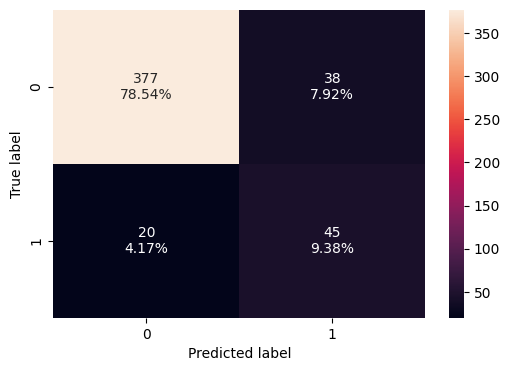

In [79]:
rf_tuned_model_train_perf = model_performance(rf_tuned, 
                                              X_train, 
                                              y_train)
print('Training performance:\n', rf_tuned_model_train_perf)
rf_tuned_model_test_perf = model_performance(rf_tuned,
                                             X_test,
                                             y_test)
print('Testing performance:\n', rf_tuned_model_test_perf)

confusion_matrix_sklearn(rf_tuned,X_test, y_test)

## Bagging Classifier

Training performance:
    Accuracy  Recall  Precision        F1
0  0.983021   0.875        1.0  0.933333
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.916667  0.584615   0.745098  0.655172


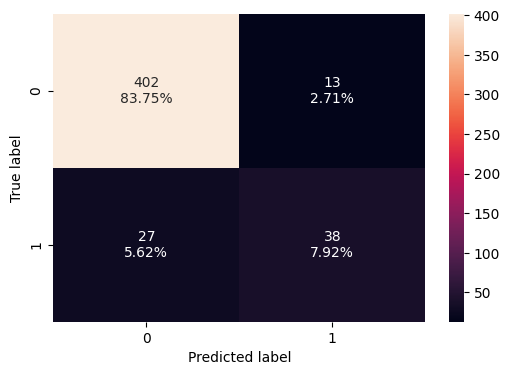

In [80]:
bagging_classifier = BaggingClassifier(random_state=1).fit(X_train,y_train)

bagging_classifier_model_train_perf=model_performance(bagging_classifier,
                                                      X_train,
                                                      y_train)
print('Training performance:\n',bagging_classifier_model_train_perf)
bagging_classifier_model_test_perf=model_performance(bagging_classifier,
                                                     X_test,
                                                     y_test)
print('Testing performance:\n',bagging_classifier_model_test_perf)

confusion_matrix_sklearn(bagging_classifier, X_test, y_test)


### Hyperparameter Tuning

In [81]:
bagging_estimator_tuned = BaggingClassifier(random_state=1)

parameters = {
    'max_samples': [0.7,0.8,0.9,1],
    'max_features': [0.7,0.8,0.9,1],
    'n_estimators': [10,20,30,40,50]}

scorer = metrics.make_scorer(metrics.f1_score)
grid_obj = GridSearchCV(bagging_estimator_tuned,
                        parameters,
                        scoring=scorer,
                        cv=5).fit(X_train, y_train)
bagging_estimator_tuned = grid_obj.best_estimator_
bagging_estimator_tuned.fit(X_train, y_train)

BaggingClassifier(max_features=0.7, max_samples=0.9, n_estimators=50,
                  random_state=1)

Training performance:
    Accuracy    Recall  Precision      F1
0  0.999106  0.993421        1.0  0.9967
Testing performance:
    Accuracy    Recall  Precision        F1
0   0.90625  0.461538       0.75  0.571429


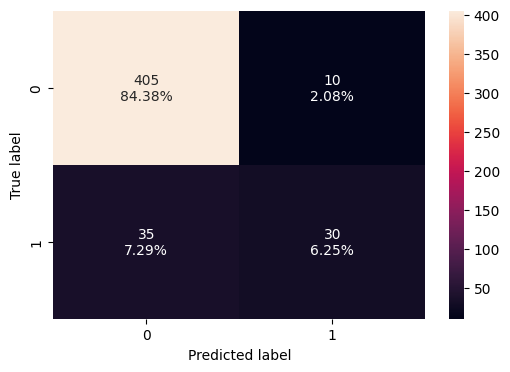

In [85]:
bagging_estimator_tuned_model_train_perf=model_performance(bagging_estimator_tuned,
                                                           X_train,
                                                           y_train)
print('Training performance:\n', bagging_estimator_tuned_model_train_perf)
bagging_estimator_tuned_model_test_perf=model_performance(bagging_estimator_tuned,
                                                          X_test,
                                                          y_test)
print('Testing performance:\n',bagging_estimator_tuned_model_test_perf)

confusion_matrix_sklearn(bagging_estimator_tuned,X_test,y_test)

## AdaBoost Classifier

Training performance:
    Accuracy    Recall  Precision        F1
0  0.913315  0.565789   0.735043  0.639405
Testing performance:
    Accuracy    Recall  Precision        F1
0     0.875  0.415385    0.55102  0.473684


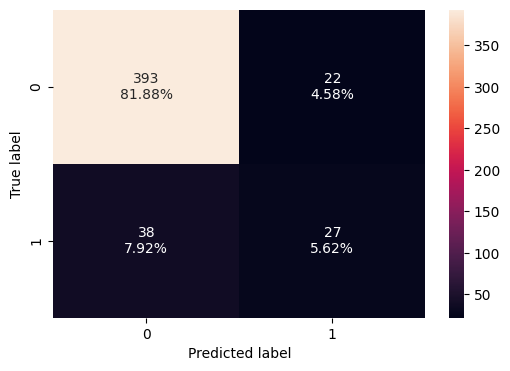

In [88]:
ab_classifier = AdaBoostClassifier(random_state=1).fit(X_train,y_train)

ab_classifier_model_train_perf=model_performance(ab_classifier,X_train,y_train)
print('Training performance:\n',ab_classifier_model_train_perf)
ab_classifier_model_test_perf=model_performance(ab_classifier,X_test,y_test)
print('Testing performance:\n',ab_classifier_model_test_perf)

confusion_matrix_sklearn(ab_classifier, X_test, y_test)

### Hyperparameter Tuning

In [91]:
abc_tuned = AdaBoostClassifier(random_state=1)

parameters = {
    'estimator':[DecisionTreeClassifier(max_depth=1),
                      DecisionTreeClassifier(max_depth=2),
                      DecisionTreeClassifier(max_depth=3)],
    'n_estimators': np.arange(10,110,10),
    'learning_rate': np.arange(0.1,2,0.1)}
    
scorer = metrics.make_scorer(metrics.f1_score)
grid_obj = GridSearchCV(abc_tuned,
                        parameters,
                        scoring=scorer,
                        cv=5).fit(X_train,y_train)
abc_tuned = grid_obj.best_estimator_
abc_tuned.fit(X_train,y_train)


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2),
                   learning_rate=1.5000000000000002, n_estimators=100,
                   random_state=1)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Testing performance:
    Accuracy    Recall  Precision       F1
0  0.908333  0.553846   0.705882  0.62069


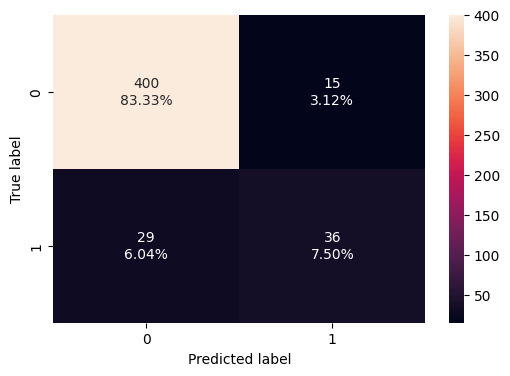

In [94]:
abc_tuned_model_train_perf = model_performance(abc_tuned,
                                               X_train,
                                               y_train)
print('Training performance:\n', abc_tuned_model_train_perf)
abc_tuned_model_test_perf = model_performance(abc_tuned,
                                              X_test,
                                              y_test)
print('Testing performance:\n', abc_tuned_model_test_perf)

confusion_matrix_sklearn(abc_tuned, X_test, y_test)

## Gradient Boosting Classifier

Training performance:
    Accuracy    Recall  Precision     F1
0  0.969616  0.782895   0.991667  0.875
Testing performance:
    Accuracy    Recall  Precision        F1
0   0.90625  0.492308   0.727273  0.587156


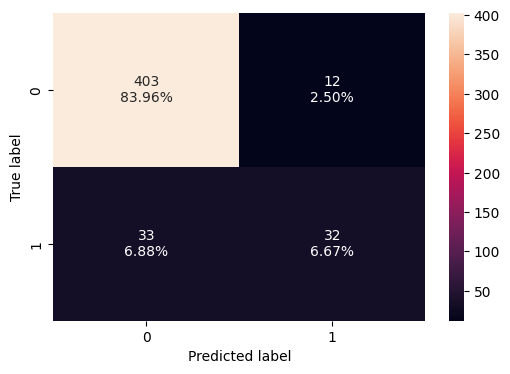

In [99]:
gb_classifier = GradientBoostingClassifier(random_state=1).fit(X_train,y_train)

gb_classifier_model_train_perf=model_performance(gb_classifier,X_train,y_train)
print("Training performance:\n",gb_classifier_model_train_perf)
gb_classifier_model_test_perf=model_performance(gb_classifier,X_test,y_test)
print("Testing performance:\n",gb_classifier_model_test_perf)

confusion_matrix_sklearn(gb_classifier,X_test,y_test)

### Hyperparameter Tuning

In [100]:
gbc_tuned = GradientBoostingClassifier(
    init=AdaBoostClassifier(random_state=1), random_state=1)

parameters = {
    'n_estimators': [100,150,200,250],
    'subsample': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9,1]}

scorer = metrics.make_scorer(metrics.f1_score)

grid_obj = GridSearchCV(gbc_tuned,
                        parameters,
                        scoring=scorer,
                        cv=5).fit(X_train,y_train)
gbc_tuned = grid_obj.best_estimator_
gbc_tuned.fit(X_train, y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           max_features=0.7, n_estimators=250, random_state=1,
                           subsample=0.9)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.993744  0.953947        1.0  0.976431
Testing performance:
    Accuracy    Recall  Precision       F1
0  0.908333  0.553846   0.705882  0.62069


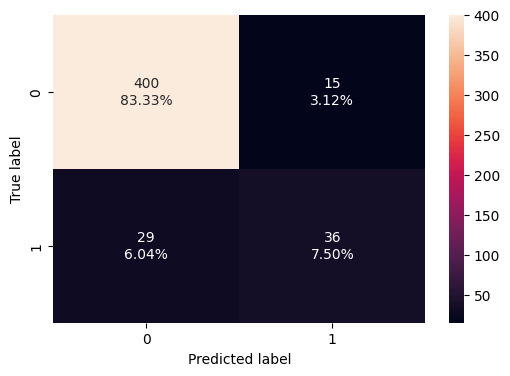

In [101]:
gbc_tuned_model_train_perf=model_performance(gbc_tuned,X_train,y_train)
print("Training performance:\n",gbc_tuned_model_train_perf)
gbc_tuned_model_test_perf=model_performance(gbc_tuned,X_test,y_test)
print("Testing performance:\n",gbc_tuned_model_test_perf)

confusion_matrix_sklearn(gbc_tuned,X_test,y_test)

## XGBoost Classifier

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Testing performance:
    Accuracy    Recall  Precision        F1
0     0.925  0.584615   0.808511  0.678571


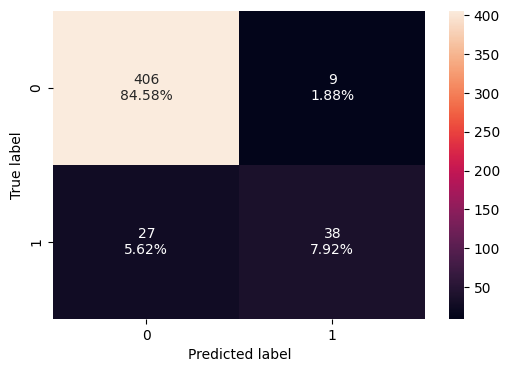

In [102]:
xgb_classifier = XGBClassifier(random_state=1,
                               eval_metric='logloss').fit(X_train,y_train)

xgb_classifier_model_train_perf=model_performance(xgb_classifier,X_train,y_train)
print("Training performance:\n",xgb_classifier_model_train_perf)
xgb_classifier_model_test_perf=model_performance(xgb_classifier,X_test,y_test)
print("Testing performance:\n",xgb_classifier_model_test_perf)

confusion_matrix_sklearn(xgb_classifier,X_test,y_test)

### Hyperparameter Tuning

In [108]:
xgb_tuned = XGBClassifier(random_state=1,
                          eval_metric='logloss')

# Grid of parameters to choose from
parameters = {
    "n_estimators": [10,30,50],
    "scale_pos_weight":[1,2,5],
    "subsample":[0.7,0.9,1],
    "learning_rate":[0.05, 0.1,0.2],
    "colsample_bytree":[0.7,0.9,1],
    "colsample_bylevel":[0.5,0.7,1]}

scorer = metrics.make_scorer(metrics.f1_score)
grid_obj = GridSearchCV(xgb_tuned,
                        parameters,
                        scoring=scorer,
                        cv=5).fit(X_train,y_train)
xgb_tuned = grid_obj.best_estimator_
xgb_tuned.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.5, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=30, n_jobs=None,
              num_parallel_tree=None, random_state=1, ...)

Training performance:
    Accuracy  Recall  Precision        F1
0  0.987489     1.0   0.915663  0.955975
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.902083  0.692308      0.625  0.656934


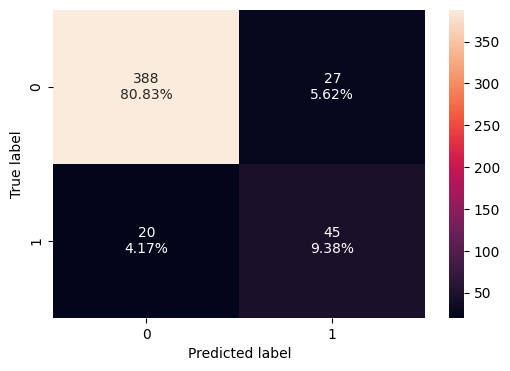

In [109]:
xgb_tuned_model_train_perf=model_performance(xgb_tuned,X_train,y_train)
print("Training performance:\n",xgb_tuned_model_train_perf)
xgb_tuned_model_test_perf=model_performance(xgb_tuned,X_test,y_test)
print("Testing performance:\n",xgb_tuned_model_test_perf)

confusion_matrix_sklearn(xgb_tuned,X_test,y_test)

## Stacking Model

In [110]:
estimators = [('Random Forest', rf_tuned),
              ('Gradient Boosting', gbc_tuned),
              ('Decision Tree', dtree_estimator)]
final_estimator = xgb_tuned

stacking_classifier = StackingClassifier(estimators=estimators,
                                         final_estimator=final_estimator)

stacking_classifier.fit(X_train,y_train)

StackingClassifier(estimators=[('Random Forest',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_depth=10,
                                                       min_samples_leaf=6,
                                                       n_estimators=50,
                                                       oob_score=True,
                                                       random_state=1)),
                               ('Gradient Boosting',
                                GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                                                           max_features=0.7,
                                                           n_estimators=250,
                                                           random_state=1,
                                                           subsample=0.9)),
                               ('Decision Tree',
                                Decision...
                                                 feature_types=None, gamma=None,
                                                 grow_policy=None,
                                                 importance_type=None,
                                                 interaction_constraints=None,
                                                 learning_rate=0.2,
                                                 max_bin=None,
                                                 max_cat_threshold=None,
                                                 max_cat_to_onehot=None,
                                                 max_delta_step=None,
                                                 max_depth=None,
                                                 max_leaves=None,
                                                 min_child_weight=None,
                                                 missing=nan,
                                                 monotone_constraints=None,
                                                 multi_strategy=None,
                                                 n_estimators=30, n_jobs=None,
                                                 num_parallel_tree=None,
                                                 random_state=1, ...))

Training performance:
    Accuracy    Recall  Precision       F1
0  0.950849  0.940789   0.756614  0.83871
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.872917  0.753846   0.521277  0.616352


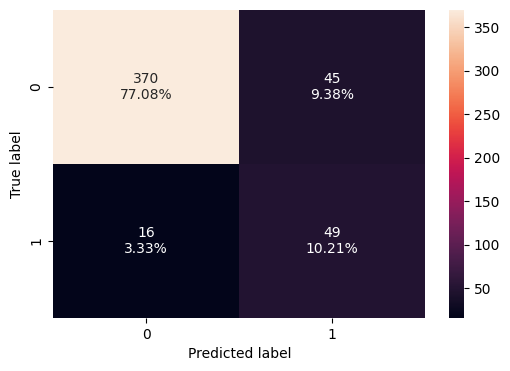

In [111]:
stacking_classifier_model_train_perf=model_performance(stacking_classifier,X_train,y_train)
print("Training performance:\n",stacking_classifier_model_train_perf)
stacking_classifier_model_test_perf=model_performance(stacking_classifier,X_test,y_test)
print("Testing performance:\n",stacking_classifier_model_test_perf)

confusion_matrix_sklearn(stacking_classifier,X_test,y_test)

## Comparing all models

In [112]:
# training performance comparison

models_train_comp_df = pd.concat(
    [d_tree_model_train_perf.T,dtree_estimator_model_train_perf.T,rf_estimator_model_train_perf.T,rf_tuned_model_train_perf.T,
     bagging_classifier_model_train_perf.T,bagging_estimator_tuned_model_train_perf.T,ab_classifier_model_train_perf.T,
     abc_tuned_model_train_perf.T,gb_classifier_model_train_perf.T,gbc_tuned_model_train_perf.T,xgb_classifier_model_train_perf.T,
    xgb_tuned_model_train_perf.T,stacking_classifier_model_train_perf.T],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree",
    "Decision Tree Estimator",
    "Random Forest Estimator",
    "Random Forest Tuned",
    "Bagging Classifier",
    "Bagging Estimator Tuned",
    "Adaboost Classifier",
    "Adabosst Classifier Tuned",
    "Gradient Boost Classifier",
    "Gradient Boost Classifier Tuned",
    "XGBoost Classifier",
    "XGBoost Classifier Tuned",
    "Stacking Classifier"]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree,Decision Tree Estimator,Random Forest Estimator,Random Forest Tuned,Bagging Classifier,Bagging Estimator Tuned,Adaboost Classifier,Adabosst Classifier Tuned,Gradient Boost Classifier,Gradient Boost Classifier Tuned,XGBoost Classifier,XGBoost Classifier Tuned,Stacking Classifier
Accuracy,1.0,0.812332,1.0,0.941019,0.983021,0.999106,0.913315,1.0,0.969616,0.993744,1.0,0.987489,0.950849
Recall,1.0,0.921053,1.0,0.953947,0.875000,0.993421,0.565789,1.0,0.782895,0.953947,1.0,1.000000,0.940789
Precision,1.0,0.414201,1.0,0.710784,1.000000,1.000000,0.735043,1.0,0.991667,1.000000,1.0,0.915663,0.756614
F1,1.0,0.571429,1.0,0.814607,0.933333,0.996700,0.639405,1.0,0.875000,0.976431,1.0,0.955975,0.838710


In [113]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [d_tree_model_test_perf.T,dtree_estimator_model_test_perf.T,rf_estimator_model_test_perf.T,rf_tuned_model_test_perf.T,
     bagging_classifier_model_test_perf.T,bagging_estimator_tuned_model_test_perf.T,ab_classifier_model_test_perf.T,
     abc_tuned_model_test_perf.T,gb_classifier_model_test_perf.T,gbc_tuned_model_test_perf.T,xgb_classifier_model_test_perf.T,
    xgb_tuned_model_test_perf.T,stacking_classifier_model_test_perf.T],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree",
    "Decision Tree Estimator",
    "Random Forest Estimator",
    "Random Forest Tuned",
    "Bagging Classifier",
    "Bagging Estimator Tuned",
    "Adaboost Classifier",
    "Adabosst Classifier Tuned",
    "Gradient Boost Classifier",
    "Gradient Boost Classifier Tuned",
    "XGBoost Classifier",
    "XGBoost Classifier Tuned",
    "Stacking Classifier"]
print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Decision Tree,Decision Tree Estimator,Random Forest Estimator,Random Forest Tuned,Bagging Classifier,Bagging Estimator Tuned,Adaboost Classifier,Adabosst Classifier Tuned,Gradient Boost Classifier,Gradient Boost Classifier Tuned,XGBoost Classifier,XGBoost Classifier Tuned,Stacking Classifier
Accuracy,0.887500,0.760417,0.918750,0.879167,0.916667,0.906250,0.875000,0.908333,0.906250,0.908333,0.925000,0.902083,0.872917
Recall,0.600000,0.876923,0.492308,0.692308,0.584615,0.461538,0.415385,0.553846,0.492308,0.553846,0.584615,0.692308,0.753846
Precision,0.582090,0.347561,0.842105,0.542169,0.745098,0.750000,0.551020,0.705882,0.727273,0.705882,0.808511,0.625000,0.521277
F1,0.590909,0.497817,0.621359,0.608108,0.655172,0.571429,0.473684,0.620690,0.587156,0.620690,0.678571,0.656934,0.616352


### Feature importance of Tuned Random Forest

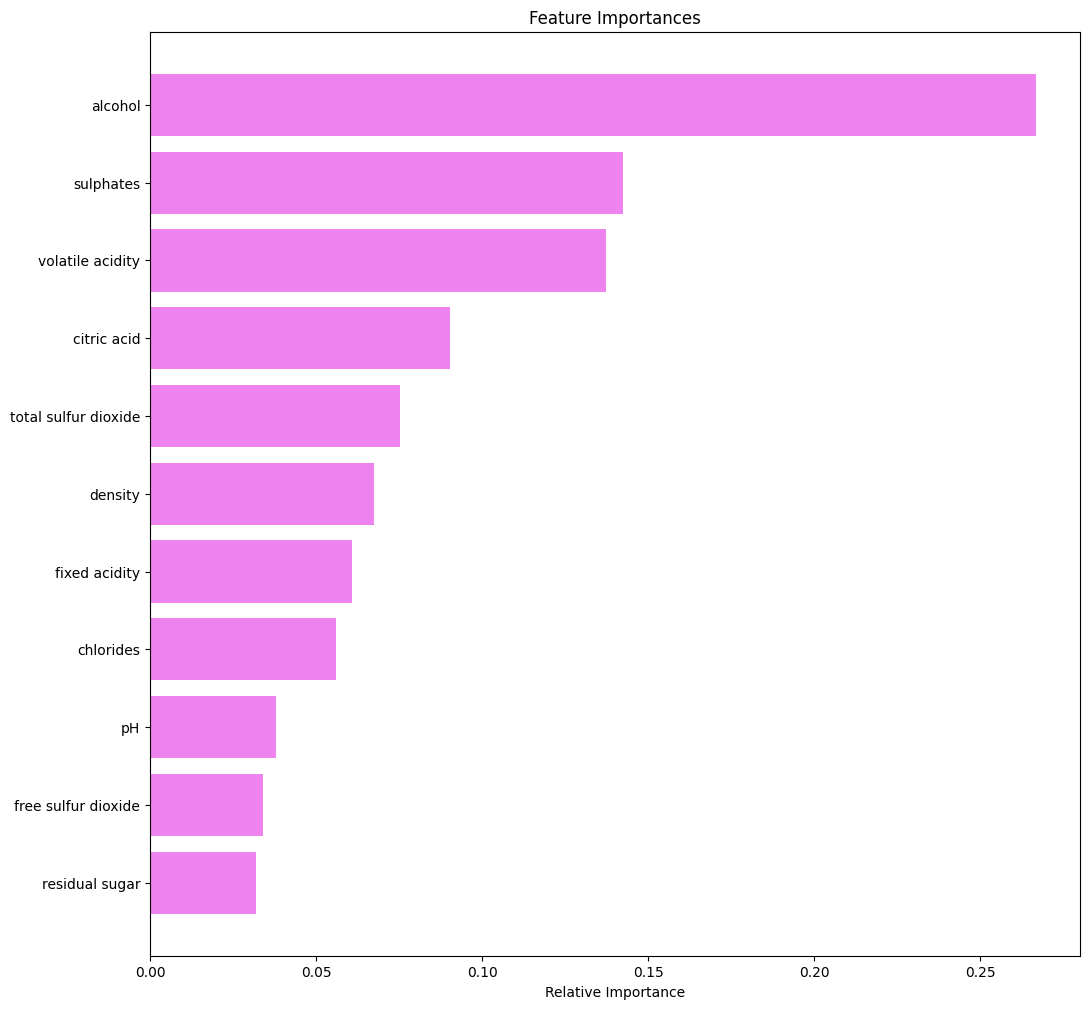

In [114]:
feature_names = X_train.columns
importances = rf_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()